# Episodic (skyline) birth–death & incomplete sampling

`EpisodicBirthDeath` lets speciation and extinction rates be **piecewise-constant through
time** — mass extinctions, shifting diversification regimes — while still simulating the
species tree *backward* and conditioned on the number of extant tips. It also supports
incomplete extant sampling via a sampling fraction ρ.

This notebook validates the sampler and shows the effect of a mass extinction and of ρ.

In [1]:
import sys, pathlib
for cand in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (cand / "zombi2" / "__init__.py").exists():
        sys.path.insert(0, str(cand)); break
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import zombi2 as z
print("zombi2", z.__version__)

zombi2 0.2.0.dev0


## 1. The sampler is correct: one epoch reproduces the analytic constant-rate CDF

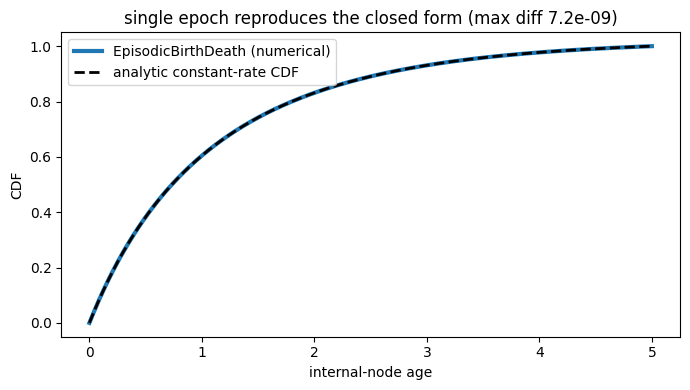

In [2]:
from scipy import stats

lam, mu, A = 1.0, 0.3, 5.0
epi = z.EpisodicBirthDeath(birth=[lam], death=[mu], shifts=[])   # a single epoch
epi._prepare(A)                                                  # build the numerical CDF
a = epi._ages
r = lam - mu
analytic = ((1 - np.exp(-r*a)) / (lam - mu*np.exp(-r*a)))
analytic /= analytic[-1]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(a, epi._cdf, lw=3, label="EpisodicBirthDeath (numerical)")
ax.plot(a, analytic, "--", lw=2, color="k", label="analytic constant-rate CDF")
ax.set_xlabel("internal-node age"); ax.set_ylabel("CDF"); ax.legend()
ax.set_title(f"single epoch reproduces the closed form (max diff {np.max(np.abs(epi._cdf-analytic)):.1e})")
plt.tight_layout(); plt.show()
assert np.max(np.abs(epi._cdf - analytic)) < 1e-4

## 2. A mass extinction

Two epochs: gentle extinction in the recent past (age < 1), a strong extinction pulse
before that. We compare against a constant-rate tree with the same recent rates.

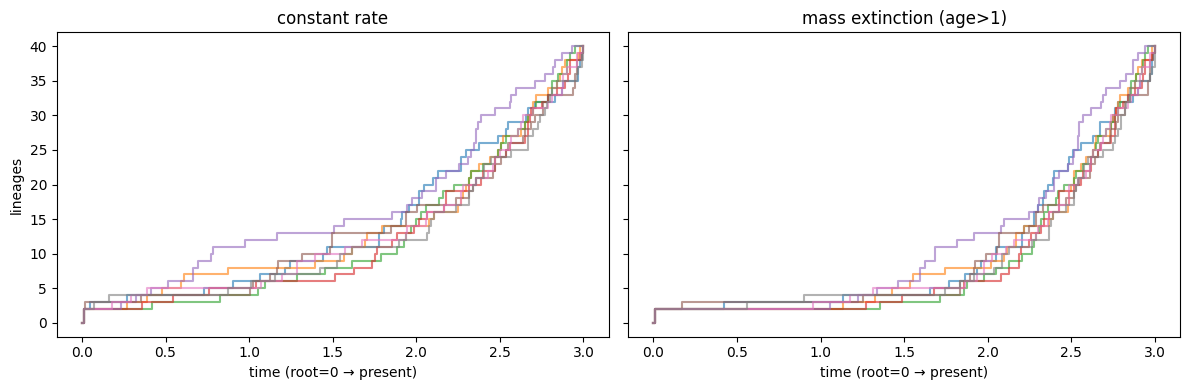

mean internal-node age — constant: 0.934 | mass extinction: 0.632


In [3]:
mass_ext = z.EpisodicBirthDeath(birth=[1.0, 1.0], death=[0.2, 3.0], shifts=[1.0])
constant = z.BirthDeath(1.0, 0.2)

def ltt(tree, npts=300):
    ts = np.linspace(tree.root.time, tree.total_age, npts)
    return ts, [len(tree.branches_alive_at(t)) for t in ts]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (model, title) in zip(axes, [(constant, "constant rate"),
                                     (mass_ext, "mass extinction (age>1)")]):
    for s in range(8):
        tr = z.simulate_species_tree(model, n_tips=40, age=3.0, seed=s)
        ts, k = ltt(tr); ax.step(ts, k, where="post", alpha=0.6)
    ax.set_title(title); ax.set_xlabel("time (root=0 → present)")
axes[0].set_ylabel("lineages")
plt.tight_layout(); plt.show()

# a mass extinction older than the recent epoch leaves a burst of recent branching
depths = lambda m: np.concatenate([[tr.total_age - n.time for n in
    z.simulate_species_tree(m, n_tips=60, age=3.0, seed=s).internal_nodes()] for s in range(20)])
print("mean internal-node age — constant:", round(depths(constant).mean(), 3),
      "| mass extinction:", round(depths(mass_ext).mean(), 3))

## 3. Incomplete extant sampling (ρ)

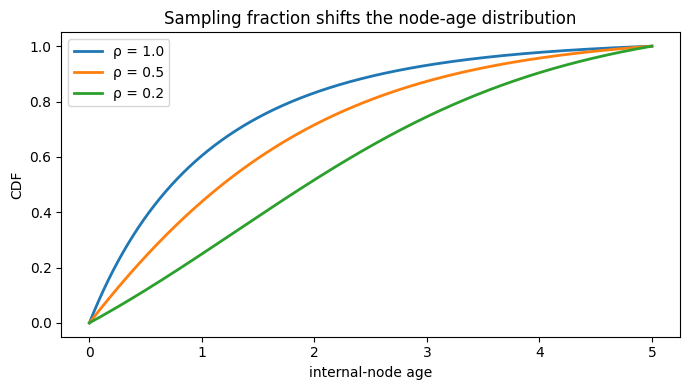

ρ=0.25 tree: 15 tips, ultrametric: True


In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for rho in (1.0, 0.5, 0.2):
    m = z.EpisodicBirthDeath(birth=[1.0], death=[0.3], shifts=[], sampling_fraction=rho)
    m._prepare(5.0)
    ax.plot(m._ages, m._cdf, lw=2, label=f"ρ = {rho}")
ax.set_xlabel("internal-node age"); ax.set_ylabel("CDF")
ax.set_title("Sampling fraction shifts the node-age distribution"); ax.legend()
plt.tight_layout(); plt.show()

tree = z.simulate_species_tree(
    z.EpisodicBirthDeath([1.0], [0.3], [], sampling_fraction=0.25), n_tips=15, age=5.0, seed=1)
print("ρ=0.25 tree:", len(tree.leaves()), "tips, ultrametric:",
      all(abs(l.time - tree.total_age) < 1e-9 for l in tree.leaves()))

## Scope

This models episodic *diversification* and incomplete *extant* sampling — both keep the
tree ultrametric. Serial sampling *through time* (dated tips / fossils, the fossilized
birth–death process) needs forward simulation with retained extinct lineages and is on the
roadmap, not implemented here.